In [8]:
import torch
import numpy as np
import cv2
from ultralytics import YOLO
import segmentation_models_pytorch as smp

In [9]:
deeplab_model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,  # ⚠️ ВАЖНО
    in_channels=3,
    classes=3
)

In [10]:
# YOLO (instance)
yolo_model = YOLO(r"E:\Education\4 course 2 semester\Practice\panoptic_project\notebooks\runs\segment\runs_instanse\lars_yolo\weights\best.pt")

# DeepLab (semantic)
deeplab_model.load_state_dict(torch.load(r"E:\Education\4 course 2 semester\Practice\panoptic_project\notebooks\deeplab_lars_30.pth"))
deeplab_model = deeplab_model.cuda()
deeplab_model.eval()

DeepLabV3Plus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

In [11]:
PANOPTIC_COLORS = {
    0: (0, 0, 255),      # water
    1: (135, 0, 235),  # sky
    2: (0, 255, 0),      # obstacle

    11: (255, 0, 0),     # ship
    12: (255, 255, 0),   # buoy
    13: (255, 0, 255),   # swimmer
    14: (0, 255, 255),   # animal
    15: (100, 0, 0),     # ship
    16: (255, 100, 0),   # buoy
    17: (255, 0, 100),   # swimmer
    18: (100, 255, 255),
}

In [12]:
YOLO_TO_PANOPTIC = {
    0: 11,  # ship
    1: 12,  # buoy
    2: 13,  # swimmer
    3: 14,  # animal
    4: 15,  # ship
    5: 16,  # buoy
    6: 17,  # swimmer
    7: 18, 
}

In [13]:
def panoptic_fusion(image_bgr):
    h, w = image_bgr.shape[:2]

    # ===== DeepLab =====
    img_dl = cv2.resize(image_bgr, (640, 640))
    img_dl = cv2.cvtColor(img_dl, cv2.COLOR_BGR2RGB)
    img_dl = img_dl.astype(np.float32) / 255.0

    img_tensor = torch.from_numpy(img_dl).permute(2,0,1).unsqueeze(0).cuda()

    with torch.no_grad():
        sem_pred = deeplab_model(img_tensor)
        sem_pred = torch.argmax(sem_pred, dim=1).squeeze().cpu().numpy()

    sem_pred = cv2.resize(sem_pred, (w, h), interpolation=cv2.INTER_NEAREST)

    # ===== YOLO =====
    yolo_results = yolo_model(image_bgr, imgsz=640, conf=0.3)[0]

    panoptic_map = sem_pred.copy()

    if yolo_results.masks is not None:
        masks = yolo_results.masks.data.cpu().numpy()
        classes = yolo_results.boxes.cls.cpu().numpy().astype(int)

        for i in range(len(masks)):
            mask = masks[i]
            cls = classes[i]

            mask = cv2.resize(mask, (w, h))
            mask = mask > 0.5

            panoptic_class = YOLO_TO_PANOPTIC.get(cls, 2)

            panoptic_map[mask] = panoptic_class

    return panoptic_map

In [14]:
def visualize_panoptic(image, panoptic_map):
    color_mask = np.zeros_like(image)

    for cls, color in PANOPTIC_COLORS.items():
        color_mask[panoptic_map == cls] = color

    overlay = 0.6 * image + 0.4 * color_mask
    overlay = overlay.astype(np.uint8)

    return overlay


0: 384x640 (no detections), 159.0ms
Speed: 2.5ms preprocess, 159.0ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


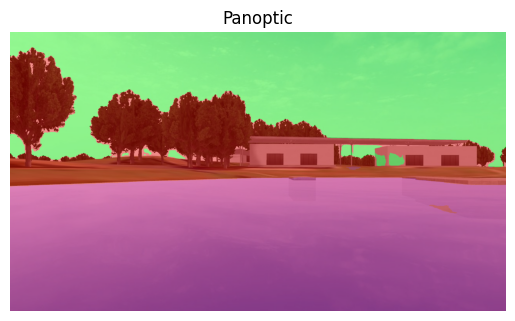

In [15]:
import matplotlib.pyplot as plt

img = cv2.imread(r"E:\Education\4 course 2 semester\Practice\panoptic_project\Video\photo_2026-04-12_21-28-44.jpg")

panoptic = panoptic_fusion(img)
result = visualize_panoptic(img, panoptic)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Panoptic")
plt.axis("off")
plt.show()